In [1]:
# Import required packages
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## Task 1
In Task 1, we denote $\mathbb{1}$ as a vector of ones; while we denote $\mathbb{1}^\top$ as the transpose of the ones' vector.  
Meanwhile, we denote $\mathbf{w}$ as a vector of asset weights; $\mathbf{w}^\top$ as the transpose of the weights' vector.  
We use FOC as short to 'First Order Condition'; w.r.t. as short to 'with respect to'.

### Task (1a)
Given,
$$
f(w) = \text{argmin}_\mathbf{w} \frac{1}{2} \mathbf{w}^\top \Sigma \mathbf{w}, \quad \text{with constraints: } \mathbf{w}^\top \mathbb{1} = 1 \text{ and } \mathbf{w}^\top \mu = m.
$$

We formulate the Lagrangian,
$$
\mathcal{L}(\mathbf{w}, \lambda_1, \lambda_2) = \frac{1}{2} \mathbf{w}^\top \Sigma \mathbf{w} + \lambda_1(1 - \mathbf{w}^\top \mathbb{1}) + \lambda_2(m - \mathbf{w}^\top \mu), \quad \text{where } \mathbf{w}^\top \mathbb{1}= \mathbb{1}^\top \mathbf{w} \text{ and } \mathbf{w}^\top \mu = \mu^\top \mathbf{w}.
$$


We perform FOC w.r.t. $\mathbf{w}, \lambda_1, \lambda_2$, and set each of the partial derivatives to zero to identify the candidates:
$$
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} &= \Sigma \mathbf{w} - \lambda_1 \mathbb{1} - \lambda_2 \mu = 0, \\
\frac{\partial \mathcal{L}}{\partial \mathbf{\lambda_1}} &= 1 - \mathbf{w}^\top \mathbb{1} = 0, \\
\frac{\partial \mathcal{L}}{\partial \mathbf{\lambda_2}} &= m - \mathbf{w}^\top \mu = 0.
\end{aligned}
$$
FOC is completed.

### Task (1b)
To compute the intermediate values $A, B, C, D$, we first have to solve the partial solution for $\mathbf{w}^*$. From $\frac{\partial \mathcal{L}}{\partial \mathbf{w}}$,
$$
\mathbf{w}^* = \Sigma^{-1}(\lambda_1 \mathbb{1} + \lambda_2 \mu)
$$

We substitute $\mathbf{w}^*$ into the predefined constraints.
For $\mathbb{1}^\top \mathbf{w}$:
$$
\begin{aligned}
\mathbb{1}^\top(\Sigma^{-1}(\lambda_1 \mathbb{1} + \lambda_2 \mu)) &= 1 \\
\lambda_1 \mathbb{1}^\top \Sigma^{-1} \mathbb{1} + \lambda_2 \mathbb{1}^\top \Sigma^{-1} \mu &= 1
\end{aligned}
$$
For $\mu^\top \mathbf{w}$:
$$
\begin{aligned}
\mu^\top(\Sigma^{-1}(\lambda_1 \mathbb{1} + \lambda_2 \mu)) &= m \\
\lambda_1 \mu^\top \Sigma^{-1} \mathbb{1} + \lambda_2 \mu^\top \Sigma^{-1} \mu &= m
\end{aligned}
$$

Notice that we can simplify the equations by assigning $A, B, C$ for the constants.
$$
\begin{aligned}
A &= \mathbb{1}^\top \Sigma^{-1} \mathbb{1}, \\
B &= \mathbb{1}^\top \Sigma^{-1} \mu = \mu^\top \Sigma^{-1} \mathbb{1}, \\
C &= \mu^\top \Sigma^{-1} \mu.
\end{aligned}
$$

The equations become:
$$
\begin{aligned}
A \lambda_1 + B \lambda_2 = 1 \\
B \lambda_1 + C \lambda_2 = m
\end{aligned}
$$

Using Cramer's rule gives
$$
\begin{aligned}
\lambda_1 = \frac{C - Bm}{AC - B^2}, \lambda_2 = \frac{Am - B}{AC - B^2}.
\end{aligned}
$$

We can let $D = AC - B^2$. So we have
$$
\begin{aligned}
A &= \mathbb{1}^\top \Sigma^{-1} \mathbb{1}, \\
B &= \mathbb{1}^\top \Sigma^{-1} \mu, \\
C &= \mu^\top \Sigma^{-1} \mu, \\
D &= AC - B^2.
\end{aligned}
$$

In [2]:
# Define the elements for calculation
mu = np.array([0.02, 0.07, 0.15, 0.20], dtype=float).reshape(-1, 1)
sigma = np.array([0.05, 0.12, 0.17, 0.25], dtype=float)
ones = np.ones((4, 1))
R = np.array([
    [1.0, 0.3, 0.3, 0.3],
    [0.3, 1.0, 0.6, 0.6],
    [0.3, 0.6, 1.0, 0.6],
    [0.3, 0.6, 0.6, 1.0],
], dtype=float)
Sigma = np.diag(sigma) @ R @ np.diag(sigma)
inv_Sigma = np.linalg.inv(Sigma)

# Intermediate values
a = (ones.T @ inv_Sigma @ ones).item()
b = (ones.T @ inv_Sigma @ mu).item()
c = (mu.T @ inv_Sigma @ mu).item()
d = a*c - b**2

print("The intermediate values of A, B, C, D are as follows: ")
print(f"A = {a:.4f}")
print(f"B = {b:.4f}")
print(f"C = {c:.4f}")
print(f"D = {d:.4f}")


The intermediate values of A, B, C, D are as follows: 
A = 423.6150
B = 6.8070
C = 0.9065
D = 337.6752


Above illustrates the process to derive the intermediate values of constants $A, \,B, \,C, \,D$. The intermediate values are:
- $A = 423.6150$, 
- $B = 6.8070$, 
- $C = 0.9065$, 
- $D = 337.6752$ 

### Task (1c)
We substitute $\lambda_1$ and $\lambda_2$ back into partial solution for $\mathbf{w}^*$:
$$
\begin{aligned}
\mathbf{w}^* 
&= \Sigma^{-1}(\frac{C - Bm}{D} \mathbb{1} + \frac{Am - B}{D} \mu) \\
&= \frac{1}{D} \Sigma^{-1}[(A \mu - B \mathbb{1})m + (C \mathbb{1} - B \mu)]
\end{aligned}
$$
And begin verifying the AI-computed solutions.

In [3]:
# Check portfolio constraints
m = 0.045
optimal_weights = (1 / d) * inv_Sigma @ (((a * mu - b * ones) * m) + (c * ones - b * mu))
sum_weights = optimal_weights.sum().item()
portfolio_variance = (optimal_weights.T @ Sigma @ optimal_weights).item()
portfolio_std_dev = np.sqrt(portfolio_variance)
assets = ["A", "B", "C", "D"]
portfolio_return = (optimal_weights.T @ mu).item()

# Display constraints
print('Portfolio contraints: ')
print(f"Sum of weights = {sum_weights * 100:.2f}%")
print(f"Portfolio expected return = {portfolio_return * 100:.2f}%")
print(f"Target return = {m * 100:.2f}%")

# Display optimal portfolio weights
print('\nOptimal weights: ')
for asset, w in zip(assets, optimal_weights.flatten()):
    print(f'w_{asset} = {w*100:.2f}%')

# Display portfolio risk
print('\nPortfolio risk: ')
print(f"Portfolio variance = {portfolio_variance*100:.2f}%")
print(f"Portfolio risk = {portfolio_std_dev*100:.2f}%")

Portfolio contraints: 
Sum of weights = 100.00%
Portfolio expected return = 4.50%
Target return = 4.50%

Optimal weights: 
w_A = 78.51%
w_B = 5.39%
w_C = 13.36%
w_D = 2.75%

Portfolio risk: 
Portfolio variance = 0.34%
Portfolio risk = 5.84%


Using our optimal weights formula, we verified that the AI-computed solution is accurate given the target return $m = 4.5\%$. Given the weights, the portfolio risk is $\sigma_\Pi = 5.84\%$.

### Task (1d)
Each unit invested in asset A adds much less risk than the other assets. We note that this is a minimum-variance problem optimiser with return constraint as one of the constraints. In Markowitz, for a given target return, the optimiser chooses the portfolio with the lowest variance. So an asset can receive the largest weight even if its expected return is low. Asset A has by far the lowest volatility, $\sigma_A = 5\%$ against the other assets. 

A minimum-variance portfolio depends on the covariance structure and asset A is the best diversifier. When correlation is below 1, diversification reduces portfolio variance, and lower correlation improves diversification effect. Asset A has the lowest correlation of 0.3 with all other assets. Therefore, it reduces the portfolio variance most effectively than other assets.

The target return is low at $m = 4.5\%$ which is much closer to asset A's 2% than asset C's 15% and asset D's 20%. The optimiser would allocate little weights to higher-return, higher-risk assets to lift the portfolio towards the target return, while allocating most weight to the lowest-risk asset A. 

## Task 2
### Task (2a)
We begin verifying the sensitivities for all asset 1, 2 and 3.

In [4]:
# Define the elements required for computation
mu = np.array([0, 0, 0])
sigma = np.array([0.3, 0.2, 0.15], dtype=float)
weights = np.array([0.5, 0.2, 0.3], dtype=float)

rho = np.array([
    [1.0, 0.8, 0.5],
    [0.8, 1.0, 0.3],
    [0.5, 0.3, 1.0],
], dtype=float)
Sigma = np.diag(sigma) @ rho @ np.diag(sigma)

Sigma_weights = Sigma @ weights
portfolio_variance = weights.T @ Sigma_weights
portfolio_std_dev = np.sqrt(portfolio_variance)

conf_lvl = 0.99
z_c = stats.norm.ppf(1-conf_lvl) # 1% standard normal quantile
phi_z = phi_z = stats.norm.pdf(z_c) # pdf at z_c

# Compute sensitivities
dVaR = mu + z_c * (Sigma_weights / portfolio_std_dev)
dES = mu - (phi_z / (1 - conf_lvl)) * (Sigma_weights / portfolio_std_dev)

risk_table = pd.DataFrame({
    "Assets": [1, 2, 3],
    "Weight": [f"{w:.0%}" for w in weights],
    "dVaR/dw_i": np.round(dVaR, 4),
    "dES/dw_i": np.round(dES, 4)
})

print(risk_table.to_string(index=False))

 Assets Weight  dVaR/dw_i  dES/dw_i
      1    50%    -0.6839   -0.7835
      2    20%    -0.3868   -0.4431
      3    30%    -0.2207   -0.2529


Comparing the above table to the AI-computed solution, they are the same and therefore we believe that the AI-computed solution is accurate.

### Task (2b)
All sensitivities are negative because in this question, $\mu_i = 0$ and the sensitivity formulae are
$$
\begin{aligned}
\frac{\partial \mathrm{VaR}(\mathbf{w})}{\partial w_i} &= \mu_i + z_\alpha \cdot \frac{(\Sigma \mathbf{w})_i}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}} \\
\frac{\partial \mathrm{ES}(\mathbf{w})}{\partial w_i} &= \mu_i - \frac{\phi(z_\alpha)}{1-c} \cdot \frac{(\Sigma \mathbf{w})_i}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}
\end{aligned}
$$
At confidence level $c=99\%$,
$$
z_\alpha = \Phi^{-1}(0.01) \approx -2.326 < 0.
$$
Also, from Task (2a),
$$
\Sigma \mathbf{w} =
\begin{pmatrix}
0.06135 \\
0.03470 \\
0.01980
\end{pmatrix}
$$
so each component $(\Sigma \mathbf{w})_i > 0$, and clearly $\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}} > 0$.

Therefore:
- for VaR, $z_c < 0$ and the ratio is positive, so $\frac{\partial \mathrm{VaR}}{\partial w_i} < 0$
- for ES, $\phi(z_c) > 0$, $1-c > 0$, and the ratio is positive, so the whole term after the minus sign is positive, hence $\frac{\partial \mathrm{ES}}{\partial w_i} < 0$

So all VaR and ES sensitivities are negative.

A negative $\frac{\partial \mathrm{VaR}}{\partial w_i}$ means that a small increase in the weight of asset $i$ makes the portfolio VaR more negative. Since VaR here is written as a left-tail portfolio return, a more negative value means a worse downside outcome. In portfolio management jargon, increasing exposure to that asset increases tail risk, while reducing exposure lowers tail risk.

Hence, a more negative sensitivity means that the asset has a larger marginal contribution to downside risk. In this portfolio, asset 1 has the most negative sensitivity, so increasing its weight worsens portfolio tail risk the most.


### Task (2c)
Asset 1 has the most negative sensitivity because the sensitivity is driven by its marginal contribution to portfolio risk.

Since the other terms in the formulae are the same for all assets in the portfolio, we put our focus on this ratio,
$$
\frac{(\Sigma \mathbf{w})_i}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}
$$
we can see that the asset with the largest value of $(\Sigma \mathbf{w})_i$ will have the highest sensitivity, and as discussed previously, the output from the formulae is negative and hence the sensitivity would translate to negative.

With emphasis, we computed
$$
\Sigma \mathbf{w}
=
\begin{pmatrix}
0.06135 \\
0.03470 \\
0.01980
\end{pmatrix}
$$
and it is apparent that asset 1 has the largest $(\Sigma \mathbf{w})_i$.

This is mainly attributed by three features:
- the highest own volatility, $\sigma_1 = 30\%$
- the largest portfolio weight, $w_1 = 50\%$
- the high positive correlations with the other assets, $\rho_{12}=0.8$ and $\rho_{13}=0.5$

In fact,
$$
(\Sigma \mathbf{w})_1 = 0.09(0.5) + 0.048(0.2) + 0.0225(0.3) = 0.045 + 0.0096 + 0.00675 = 0.06135
$$

The first term is large because asset 1 has both high variance and high weight, and the covariance terms are also positive and sizeable because it is positively correlated with the rest of the portfolio. Therefore, asset 1 has the largest marginal effect on portfolio variance, increasing its weight worsens VaR and ES the most. It has the most negative sensitivity.

### Task 2(d)
We let
$$
k_i=\frac{(\Sigma \mathbf{w})_i}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}
$$
Since $\mu_i=0$, the sensitivities become
$$
\begin{aligned}
\frac{\partial \mathrm{VaR}(\mathbf{w})}{\partial w_i} &= z_\alpha k_i \\
\frac{\partial \mathrm{ES}(\mathbf{w})}{\partial w_i} &= -\frac{\phi(z_\alpha)}{1-c} k_i
\end{aligned}
$$

Because $(\Sigma \mathbf{w})_i > 0$ for all assets and $\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}} > 0$, we have $k_i > 0$ for all $i$. Therefore,
$$
\left|\frac{\partial \mathrm{VaR}}{\partial w_i}\right| = |z_\alpha| k_i \qquad \text{and} \qquad \left|\frac{\partial \mathrm{ES}}{\partial w_i}\right| = \frac{\phi(z_\alpha)}{1 - c} k_i
$$
We compare the constants:
$$
|z_\alpha|=|\Phi^{-1}(0.01)| \approx 2.326 \qquad \text{and} \qquad \frac{\phi(z_\alpha)}{1-c} = \frac{\phi(-2.326)}{0.01} \approx \frac{0.02665}{0.01} \approx 2.665
$$
Since $2.326 < 2.665$, it follows that
$$
\left|\frac{\partial \mathrm{VaR}}{\partial w_i}\right| < \left|\frac{\partial \mathrm{ES}}{\partial w_i}\right| \qquad \text{for all assets } i
$$

According to the fundamental definition, ES is more sensitive than VaR because VaR only looks at the cutoff point of the $1\%$ tail, whereas ES looks at the average loss beyond that cutoff. Since ES accounts for the severity of losses inside the tail, its marginal risk sensitivity is larger in absolute value.

## Task 3
### Task (3a)

In [5]:
# Read S&P 500 price data into dataframe
gspc = pd.read_excel('Indices_Download_2026.xlsx', usecols=['Date', '^GSPC'])

# Manipulate the base dataframe
gspc = gspc.rename(columns={
    'Date': 'date',
    '^GSPC': 'price'
})
gspc['date'] = pd.to_datetime(gspc['date'])
gspc['log_return'] = np.log(gspc['price'] / gspc['price'].shift(1))

horizon = 10
gspc['forward10d_return'] = np.log(gspc['price'].shift(-horizon) / gspc['price'])

# Extract S&P 500 2025-2026 data sample
gspc_1yr_sample = gspc[(gspc['date']>='2025-01-01') & (gspc['date']<='2026-01-15')].dropna()

# Manipulate S&P 500 data sample for 21-day rolling VaR backtest model
gspc_rolling21d = gspc_1yr_sample.copy()
gspc_rolling21d['rolling21d_std'] = gspc['log_return'].rolling(21).std()

gspc_rolling21d['scaled10d_std'] = gspc_rolling21d['rolling21d_std'] * np.sqrt(horizon)
gspc_rolling21d['10d_VaR'] = stats.norm.ppf(1-conf_lvl) * gspc_rolling21d['scaled10d_std']

# Rearrange columns
gspc_rolling21d = gspc_rolling21d[[
    'date',
    'price',
    'log_return',
    'rolling21d_std',
    'scaled10d_std',
    '10d_VaR',
    'forward10d_return'
]]

# Display S&P 500 data subset for VaR backtesting (21-day rolling std-dev)
print('S&P 500 2025-2026 data sample head: \n ', '-' * 100)
print(gspc_rolling21d.head(5))
print('\nS&P 500 2025-2026 data sample tail: \n ', '-' * 100)
print(gspc_rolling21d.tail(5))

S&P 500 2025-2026 data sample head: 
  ----------------------------------------------------------------------------------------------------
           date        price  log_return  rolling21d_std  scaled10d_std  \
2318 2025-01-02  5868.549805   -0.002226        0.009015       0.028508   
2319 2025-01-03  5942.470215    0.012517        0.009511       0.030078   
2320 2025-01-06  5975.379883    0.005523        0.009494       0.030021   
2321 2025-01-07  5909.029785   -0.011166        0.009755       0.030849   
2322 2025-01-08  5918.250000    0.001559        0.009739       0.030798   

       10d_VaR  forward10d_return  
2318 -0.066318           0.021595  
2319 -0.069972           0.017808  
2320 -0.069840           0.018404  
2321 -0.071766           0.034870  
2322 -0.071647           0.030451  

S&P 500 2025-2026 data sample tail: 
  ----------------------------------------------------------------------------------------------------
           date        price  log_return  rolling21d

The table above shows the top 5 and bottom 5 rows of the subset of S&P 500 data from 01 Jan 2025 to 15 Jan 2026.

It is constructed as follows:
- `price`: daily S&P 500 index level, directly retrieved from the provided data file 
- `log_return`: 1-day log return
- `rolling21d_std`: rolling 21 trading day standard deviation of daily log returns
- `scaled10d_std`: 10-day volatility estimate obtained by scaling daily volatility by the square root of 10
- `10d_VaR`: 99% parametric 10-day Value-at-Risk, computed from the 10-day volatility under a Normal return assumption
- `forward10d_return`: realised 10-day forward log return, computed from the price 10 trading days ahead relative to the current price

Assumptions:
- returns are measured as log returns
- the rolling 21-day standard deviation is a proxy for current daily volatility
- 10-day volatility follows square-root-of-time scaling
- 10-day returns are approximately Normally distributed
- the VaR estimate uses volatility only and does not include a drift term

$$
\begin{aligned}
\mu_{10D} &= 10 \mu_{1D} \\
\sigma_{10D} &= \sigma_{1D} \sqrt{10} \\
r_{10D} &\sim N(\mu_{10D}, \sigma_{10D}^2)
\end{aligned}
$$

Note that because `forward10d_return` uses `shift(-10)`, observations near the sample end rely on prices beyond 15 Jan 2026.

We proceed to work on the counts and percentage of VaR breaches.

In [6]:
# Create a column to count the total number of VaR breaches
gspc_rolling21d['VaR_breach'] = (
    gspc_rolling21d['forward10d_return'] < gspc_rolling21d['10d_VaR']
    ).astype(int)

start_date = gspc_rolling21d['date'].iloc[0].strftime('%d %b %Y')
end_date = gspc_rolling21d['date'].iloc[-1].strftime('%d %b %Y')
sum_breaches = gspc_rolling21d['VaR_breach'].sum()
percent_breaches = gspc_rolling21d['VaR_breach'].sum() / len(gspc_rolling21d)

print(
    f'The total count of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated using a 21-day rolling standard deviation) is {sum_breaches}.'
    )
print(
    f'The percentage of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated using a 21-day rolling standard deviation) is '
    f'{(percent_breaches * 100):.2f}%.'
    )

The total count of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated using a 21-day rolling standard deviation) is 10.
The percentage of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated using a 21-day rolling standard deviation) is 3.85%.


Using the condition $r_t^{(10D)} < \mathrm{VaR}_{t, \,0.99}^{(10D)}$ to identify the VaR breaches, the 99% 10 Day VaR (21-day rolling std-dev) found that there are 10 VaR breaches in total, accounting for 3.85% over the 1 year sample period 02 Jan 2025 to 15 Jan 2026 on S&P 500. The empirical observed breach rate is above the theoretical 1% breach rate implied by a 99% parametric VaR model.

### Task (3b)

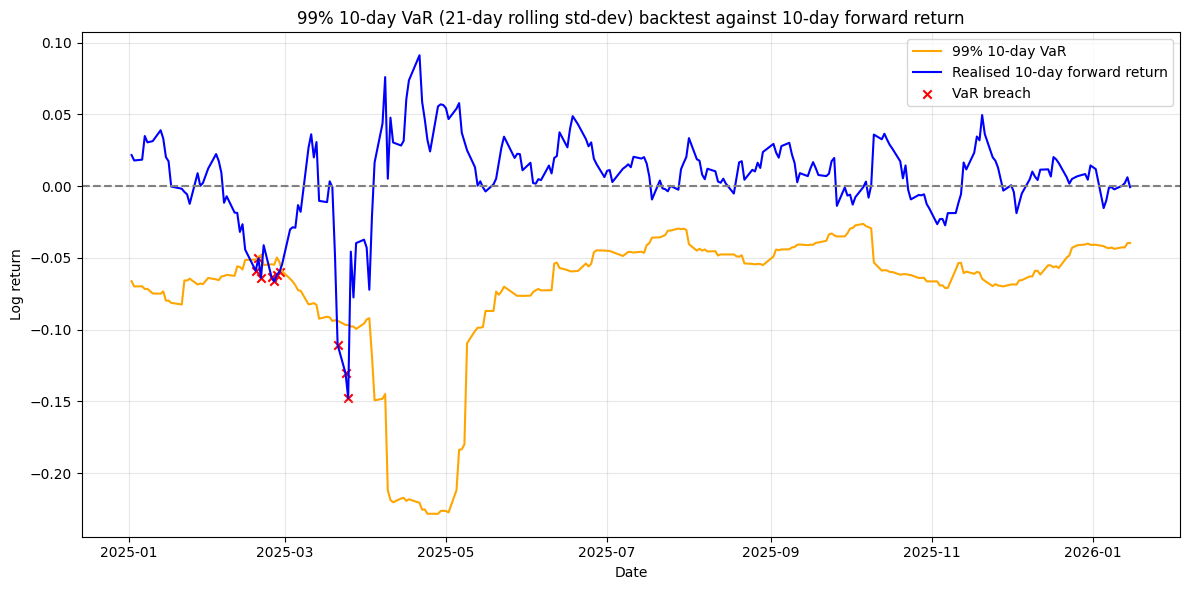

In [7]:
# Identify breach points
rolling21d_breaches = gspc_rolling21d[gspc_rolling21d['VaR_breach'] == 1]

# Plot 99% 10-day VaR against realised 10-day forward return
plt.figure(figsize=(12, 6))

plt.plot(
    gspc_rolling21d['date'],
    gspc_rolling21d['10d_VaR'],
    label='99% 10-day VaR',
    color='orange'
)
plt.plot(
    gspc_rolling21d['date'],
    gspc_rolling21d['forward10d_return'],
    label='Realised 10-day forward return',
    color='blue'
)
plt.scatter(
    rolling21d_breaches['date'],
    rolling21d_breaches['forward10d_return'],
    marker='x',
    label='VaR breach',
    color='red'
)

plt.axhline(0, color='grey', linestyle='--')
plt.title('99% 10-day VaR (21-day rolling std-dev) backtest against 10-day forward return')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

From the above figure, we have:
- blue line to represent the realised 10-day forward return
- orange line to represent 99% 10-day VaR based on 21-day rolling std-dev
- red cross marks to represent the points where the 99% 10-day VaR is breached

As the 10-day forward return falls below the 99% 10-day VaR threshold, breaches are marked by red crosses. These cluster in Feb–Apr 2025, indicating a volatility regime shift. The parametric VaR underestimates tail risk during this period due to lagged volatility estimation and distributional assumptions. Risk is underestimated pre-shock and overestimated post-shock, behaving as expected from a VaR based on backward-looking 21-day rolling volatility input. The empirical clustering of breaches suggests serial dependence, violating the i.i.d. assumption. The model performs adequately in stable regimes but fails during extreme downside events.

### Task (3c)
For the traffic-light classification, the number of VaR breaches is assumed to follow
$$
B \sim \text{Binomial}(T, 0.01)
$$
where $T$ is the number of eligible comparisons and $0.01$ is the expected breach probability for a 99\% VaR model.

From Task (3a), the sample gives $T = 260$ and $b = 10$.

The green cutoff $q_G$ is defined by
$$
q_G = \inf\{q: \Pr(B \le q) \ge 0.95\}
$$

The yellow cutoff $q_Y$ is defined by
$$
q_Y = \inf\{q: \Pr(B \le q) \ge 0.9999\}
$$

In [8]:
# Define the elements for binomial model
T = len(gspc_rolling21d)
b = sum_breaches

# traffic-light thresholds
p = 1 - conf_lvl
p_G = 0.95
p_Y = 0.9999

q_G = stats.binom.ppf(p_G, T, p)
q_Y = stats.binom.ppf(p_Y, T, p)

# Determine the zone
if b <= q_G:
    zone = "Green"
elif b <= q_Y:
    zone = "Yellow"
else:
    zone = "Red"

print(f"Green zone threshold = {int(q_G)}")
print(f"Yellow zone threshold = {int(q_Y)}")
print(f"Traffic-light zone = {zone} zone")

Green zone threshold = 5
Yellow zone threshold = 10
Traffic-light zone = Yellow zone


We classify the VaR backtesting result using the binomial traffic-light framework specified in the question. Under the null hypothesis of a 99% VaR model, the number of breaches follows a Binomial distribution with parameters $T$ and $0.01$.

Using the number of eligible comparisons from Task (3a), $T = 260$, and the observed number of breaches, $b = 10$, the green zone binomial percentile threshold is $q_G = 5$; while yellow zone threshold is $q_Y = 10$. Since the observed breach count satisfies $5 < 10 \le 10$, the model falls into the yellow zone.

This implies the realised number of breaches is higher than would normally be expected for a 99% VaR model, but not high enough to fall into the red zone. In practical terms, the backtest raises concerns about the adequacy of the VaR model, suggesting that the model may be underestimating downside risk over the sample period.

## Task 4
### Task (4a)
Using EWMA volatility forecast as follows:
$$
\sigma^2_{t+1 | t} = \lambda \sigma^2_{t | t-1} + (1 - \lambda) r^2_t
$$
where $\lambda = 0.72$ to construct parametric VaR model and utilise the same condition to identify VaR breaches as follows:
$$
\mathrm{VaR}_{t, \,0.99}^{(10D)} = \Phi^{-1}(1-c) \times \sigma_T \times \sqrt{10} 
$$

$$
r_t^{(10D)} < \mathrm{VaR}_{t, \,0.99}^{(10D)} 
$$
where $r_t^{(10D)}$ is the same 10-day forward return that we computed in Task 3; $\mathrm{VaR}_{t, \,0.99}^{(10D)}$ is the Value-at-Risk based on volatility forecasted using EWMA, used to estimate the next 10 days' loss.

In [9]:
# Manipulate previous sample dataframe for EWMA
gspc_ewma = gspc_1yr_sample.copy()
gspc_ewma['squared_return'] = gspc_ewma['log_return'] ** 2
gspc_ewma['ewma_var'] = np.nan
gspc_ewma.loc[gspc_ewma.index[0], 'ewma_var'] = gspc_ewma['squared_return'].mean()

# Recursive EWMA: \sigma^2_{t+1|t} = \lambda \sigma^2_{t|t-1} + (1 - \lambda) r^2_t
lam = 0.72

for i in range(1, len(gspc_ewma)):
    gspc_ewma.loc[gspc_ewma.index[i], 'ewma_var'] = (
        lam * gspc_ewma.loc[gspc_ewma.index[i-1], 'ewma_var']
        + (1-lam) * gspc_ewma.loc[gspc_ewma.index[i-1], 'squared_return']
    )

# 10D volatility forecast and 99% 10D VaR threshold
gspc_ewma['scaled10d_std'] = np.sqrt(gspc_ewma['ewma_var']) * np.sqrt(horizon)
gspc_ewma['10d_VaR'] = stats.norm.ppf(1-conf_lvl) * gspc_ewma['scaled10d_std']

# Rearrange dataframe column
gspc_ewma = gspc_ewma[[
    'date',
    'price',
    'log_return',
    'squared_return',
    'ewma_var',
    'scaled10d_std',
    '10d_VaR',
    'forward10d_return',
    ]]

# Display S&P 500 data subset for VaR backtesting (EWMA std-dev)
print('S&P 500 2025-2026 data sample head: \n ', '-' * 100)
print(gspc_ewma.head(5))
print('\nS&P 500 2025-2026 data sample tail: \n ', '-' * 100)
print(gspc_ewma.tail(5))

S&P 500 2025-2026 data sample head: 
  ----------------------------------------------------------------------------------------------------
           date        price  log_return  squared_return  ewma_var  \
2318 2025-01-02  5868.549805   -0.002226        0.000005  0.000133   
2319 2025-01-03  5942.470215    0.012517        0.000157  0.000097   
2320 2025-01-06  5975.379883    0.005523        0.000031  0.000114   
2321 2025-01-07  5909.029785   -0.011166        0.000125  0.000091   
2322 2025-01-08  5918.250000    0.001559        0.000002  0.000100   

      scaled10d_std   10d_VaR  forward10d_return  
2318       0.036493 -0.084896           0.021595  
2319       0.031189 -0.072556           0.017808  
2320       0.033750 -0.078515           0.018404  
2321       0.030092 -0.070005           0.034870  
2322       0.031640 -0.073606           0.030451  

S&P 500 2025-2026 data sample tail: 
  ---------------------------------------------------------------------------------------------

The above code block and table preview shows the calculation of the new EWMA variance and EWMA standard deviation.
$$
\begin{aligned}
\sigma^2_{t+1 | t} &= \lambda \sigma^2_{t | t-1} + (1-\lambda) r^2_t \\
\sigma_{t+1 | t} &= \sqrt{\sigma^2_{t+1 | t}}
\end{aligned}
$$

In [10]:
# Create a column to count the total number of VaR breaches
gspc_ewma['VaR_breach'] = (
    gspc_ewma['forward10d_return'] < gspc_ewma['10d_VaR']
    ).astype(int)

start_date = gspc_ewma['date'].iloc[0].strftime('%d %b %Y')
end_date = gspc_ewma['date'].iloc[-1].strftime('%d %b %Y')
sum_breaches = gspc_ewma['VaR_breach'].sum()
percent_breaches = gspc_ewma['VaR_breach'].sum() / len(gspc_ewma)

print(
    f'The total count of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated using a EWMA standard deviation) is {sum_breaches}.'
    )
print(
    f'The percentage of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated using a EWMA standard deviation) is '
    f'{(percent_breaches * 100):.2f}%.'
    )

The total count of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated using a EWMA standard deviation) is 11.
The percentage of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated using a EWMA standard deviation) is 4.23%.


Using the condition $r_t^{(10D)} < \mathrm{VaR}_{t, \,0.99}^{(10D)}$ to identify the VaR breaches, the 99% 10 Day VaR (EWMA std-dev) found that there are 11 VaR breaches in total, accounting for 4.23% over the 1 year sample period 02 Jan 2025 to 15 Jan 2026 on S&P 500. It recorded one more exception than the VaR model based on 21-day rolling standard deviation.

### Task (4b)

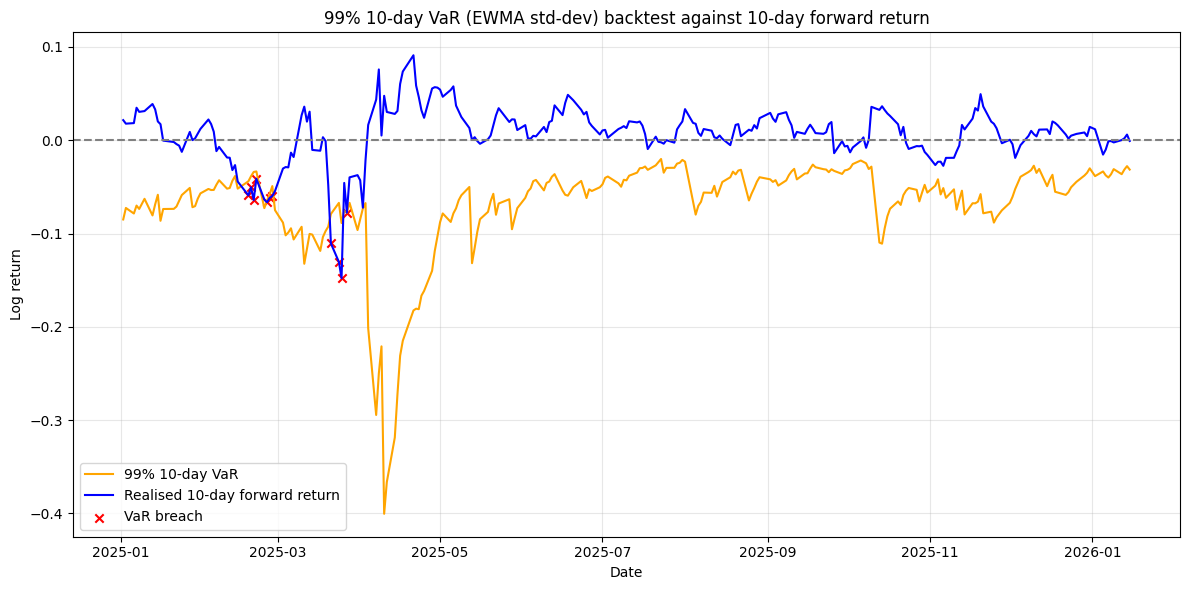

In [11]:
# Identify breach points
breach_points = gspc_ewma[gspc_ewma['VaR_breach'] == 1]

# Plot 99% 10-day VaR against realised 10-day forward return
plt.figure(figsize=(12, 6))

plt.plot(
    gspc_ewma['date'],
    gspc_ewma['10d_VaR'],
    label='99% 10-day VaR',
    color='orange'
)
plt.plot(
    gspc_ewma['date'],
    gspc_ewma['forward10d_return'],
    label='Realised 10-day forward return',
    color='blue'
)
plt.scatter(
    breach_points['date'],
    breach_points['forward10d_return'],
    marker='x',
    label='VaR breach',
    color='red'
)

plt.axhline(0, color='grey', linestyle='--')
plt.title('99% 10-day VaR (EWMA std-dev) backtest against 10-day forward return')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

From the figure:
- The blue line represents the realised 10-day forward return
- The orange line represents the 99% 10-day VaR (EWMA-based)
- Red crosses indicate VaR breaches

The tail risk during the Feb–Apr 2025 volatility regime shift period remains underestimated by the EWMA-based VaR. The additional VaR breach point appears in the right cluster.

### Task (4c)

The total count of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated via 250-day rolling historical simulation using empirical quantiles) is 13.
The percentage of 99% 10-day VaR breaches from 02 Jan 2025 to 15 Jan 2026 (VaR estimated via 250-day rolling historical simulation using empirical quantiles) is 5.00%.


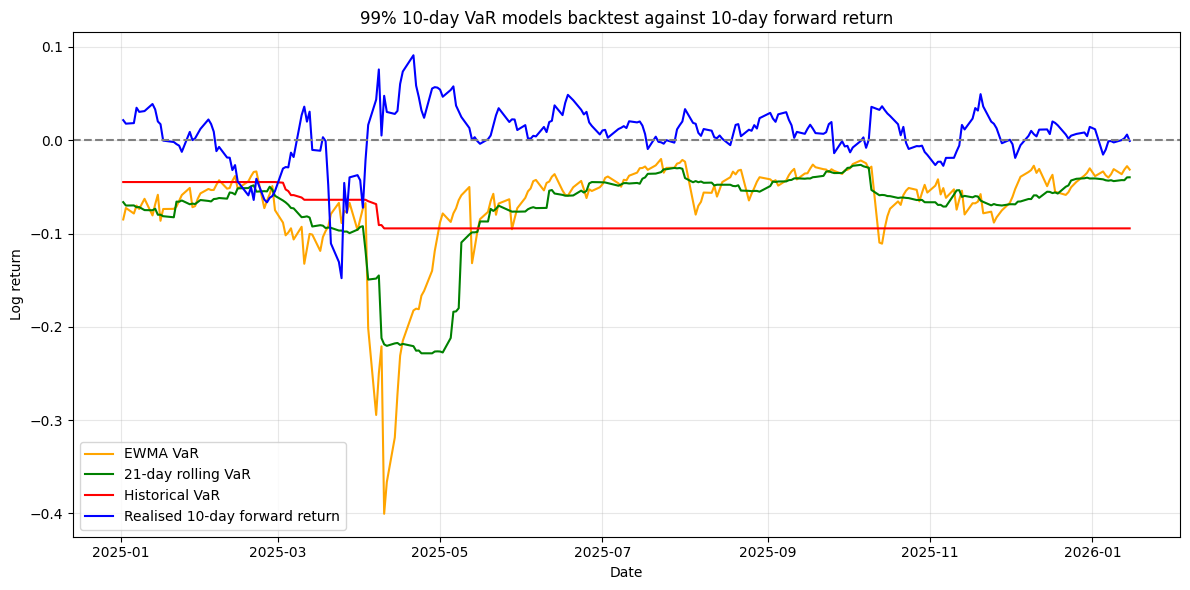

In [12]:
# Manipulate base dataframe for histsim
gspc_histsim = gspc.copy()

gspc_histsim['hist10d_return'] = np.log(gspc_histsim['price'] / gspc_histsim['price'].shift(10))

hs_window = 250
gspc_histsim['10d_VaR'] = gspc_histsim['hist10d_return'].rolling(hs_window).quantile(1-conf_lvl)

# Extract the same sample period to enable comparison
gspc_histsim = gspc_histsim[
    (gspc_histsim['date'] >= '2025-01-01') & (gspc_histsim['date'] <= '2026-01-15')
    ]

# Rearrange the columns
gspc_histsim = gspc_histsim[[
    'date',
    'price',
    'hist10d_return',
    '10d_VaR',
    'forward10d_return'
    ]]

# Identify VaR breaches against the same realised forward 10-day return
gspc_histsim['VaR_breach'] = (
    gspc_histsim['forward10d_return'] < gspc_histsim['10d_VaR']
    ).astype(int)

# Inspects simple stats 
start_date = gspc_histsim['date'].iloc[0].strftime('%d %b %Y')
end_date = gspc_histsim['date'].iloc[-1].strftime('%d %b %Y')
sum_breaches = gspc_histsim['VaR_breach'].sum()
percent_breaches = gspc_histsim['VaR_breach'].sum() / len(gspc_histsim)

print(
    f'The total count of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated via 250-day rolling historical simulation using empirical quantiles)'
    f' is {sum_breaches}.'
    )
print(
    f'The percentage of 99% 10-day VaR breaches from {start_date} to {end_date}'
    f' (VaR estimated via 250-day rolling historical simulation using empirical quantiles)'
    f' is {(percent_breaches * 100):.2f}%.'
    )

# Plot all three 99% 10-day VaR models against realised 10-day forward return
plt.figure(figsize=(12, 6))

plt.plot(
    gspc_ewma['date'],
    gspc_ewma['10d_VaR'],
    label='EWMA VaR',
    color='orange'
)
plt.plot(
    gspc_rolling21d['date'],
    gspc_rolling21d['10d_VaR'],
    label='21-day rolling VaR',
    color='green'
)
plt.plot(
    gspc_histsim['date'],
    gspc_histsim['10d_VaR'],
    label='Historical VaR',
    color='red'
)
plt.plot(
    gspc_histsim['date'],
    gspc_histsim['forward10d_return'],
    label='Realised 10-day forward return',
    color='blue'
)

plt.axhline(0, color='grey', linestyle='--')
plt.title('99% 10-day VaR models backtest against 10-day forward return')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Empirically, the ranking of volatility adaptivity over 02 Jan 2025 to 15 Jan 2026 is
- best adaptivity: 21-day rolling SD VaR
- mediocre: EWMA VaR
- worst adaptivity: Historical Simulation VaR

This ranking follows directly from the breach statistics. The 21-day rolling SD VaR records 10 breaches (3.85%), which is the lowest among the three methods. EWMA VaR records 11 breaches (4.23%). Historical Simulation VaR records 13 breaches (5.00%), which is the highest. Since a 99% VaR should ideally be breached about 1% of the time, all three methods understate risk during this sample period, but the rolling std-dev approach does so the least, while Historical Simulation does so the most.

The figure supports this conclusion visually. During the sharp volatility increase around late Feb 2025 to Apr 2025, the Historical VaR line adjusts only slowly and remains relatively flat compared with the magnitude of the realised losses. As a result, the realised 10-day forward return falls below the Historical VaR threshold more often. This is consistent with the mechanics of Historical Simulation, so a sudden change in market conditions affects the estimated left-tail quantile only gradually. In effect, the model carries too much information from older, quieter periods, which makes it slow to recognise a new high-volatility regime.

By contrast, the 21-day rolling SD VaR appears to adapt best in this dataset because it is based only on the most recent 21 observations. When a large return enters the rolling window, the estimated volatility rises quickly, so the parametric VaR widens quickly as well:
$$
\mathrm{VaR}_{t, \,0.99}^{(10D)} \propto z_{0.01} \sigma_t \sqrt{10}.
$$
This short memory makes the model highly sensitive to recent market stress. Equally importantly, once the turbulent observations leave the 21-day window, the estimated volatility also falls relatively quickly. In this sample, that short and fixed window seems to match the realised volatility regime changes better than the other two methods, which explains why it produces the fewest breaches.

Although theory would often suggest that EWMA should adapt very well to volatility because it places greater weight on recent observations, the empirical result here is slightly weaker than the rolling SD model. Under EWMA,
$$
\sigma_{t+1 | t}^2 = \lambda \sigma_{t | t-1}^2 + (1 - \lambda)r_t^2,
$$
with $\lambda = 0.72$. This implies the model does respond immediately to new shocks, since the latest squared return enters directly into the variance update. However, unlike the rolling SD model, older information is never removed completely, it only decays geometrically over time. Hence EWMA is more responsive than Historical Simulation, but less aggressive than the 21-day rolling SD in this sample. That intermediate behaviour is reflected in the backtest result of 11 breaches, which is slightly worse than rolling SD but better than Historical Simulation.

Overall, despite the theoretical appeal of EWMA, the realised backtest shows that the 21-day rolling SD VaR exhibits the best adaptivity to volatility in this particular sample, while Historical Simulation exhibits the worst. EWMA lies in between in which it reacts faster than Historical Simulation, but not quite well enough to outperform the shorter rolling window approach here.